In [1]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt 

2025-12-21 10:54:07.294703: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766314447.506454      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766314447.567566      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
DATA_DIR = "/kaggle/input/vegetable-image-dataset/Vegetable Images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 15

Writing the parameters for all models to ensure justice in comparison

/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Capsicum/0150.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Cucumber/1353.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Papaya/0986.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Broccoli/0612.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/test/Capsicum/1008.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Carrot/0638.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Cauliflower/1435.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1374.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/test/Bitter_Gourd/1231.jpg → Size: 224 x 224
/kaggle/input/vegetable-image-dataset/Vegetable Images/train/Bitter_Gourd/0430.jpg → Size: 224 x 193


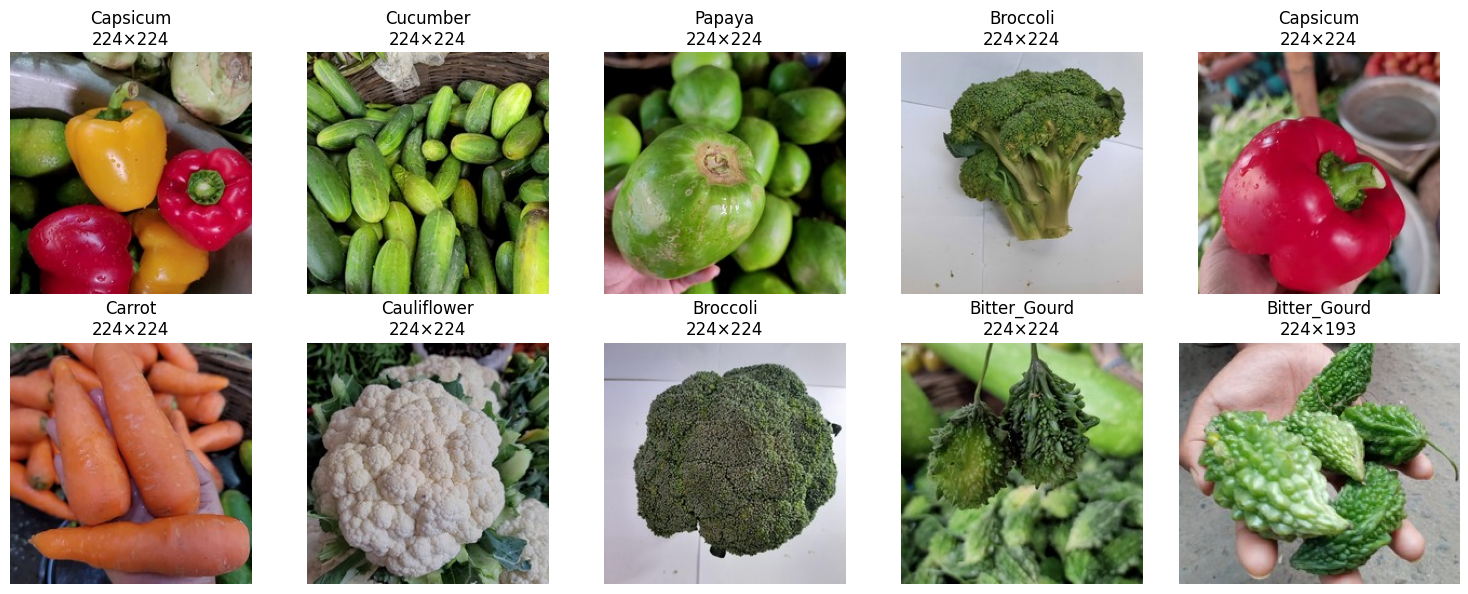

In [3]:
image_paths = []

# Traverse: split → class → image
for split in ["train", "validation", "test"]:
    split_path = os.path.join(DATA_DIR, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if os.path.isfile(img_path):
                    image_paths.append(img_path)

# Randomly select 10 images
sampled_images = random.sample(image_paths, 10)

# Plot images and print sizes
plt.figure(figsize=(15, 6))

for i, img_path in enumerate(sampled_images):
    img = Image.open(img_path)
    width, height = img.size

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(
        f"{os.path.basename(os.path.dirname(img_path))}\n{width}×{height}"
    )
    plt.axis("off")

    print(f"{img_path} → Size: {width} x {height}")

plt.tight_layout()
plt.show()


Ploting 10 random images with it's size from the dataset to know the size of the images in the dataset

In [4]:
import os

def count_images(root_dir):
    print("Dataset structure under:", root_dir)

    for split in ["train", "validation", "test"]:
        split_path = os.path.join(root_dir, split)

        if not os.path.isdir(split_path):
            print(f"\n Split folder not found: {split_path}")
            continue

        print(f"\nSplit: {split}")
        total = 0

        class_folders = sorted(os.listdir(split_path))

        for cls in class_folders:
            cls_path = os.path.join(split_path, cls)

            if not os.path.isdir(cls_path):
                continue

            n = len([
                name for name in os.listdir(cls_path)
                if os.path.isfile(os.path.join(cls_path, name))
            ])

            print(f"  {cls:15s}: {n}")
            total += n

        print(f"  → Total images in {split}: {total}")
        
count_images(DATA_DIR)

Dataset structure under: /kaggle/input/vegetable-image-dataset/Vegetable Images

Split: train
  Bean           : 1000
  Bitter_Gourd   : 1000
  Bottle_Gourd   : 1000
  Brinjal        : 1000
  Broccoli       : 1000
  Cabbage        : 1000
  Capsicum       : 1000
  Carrot         : 1000
  Cauliflower    : 1000
  Cucumber       : 1000
  Papaya         : 1000
  Potato         : 1000
  Pumpkin        : 1000
  Radish         : 1000
  Tomato         : 1000
  → Total images in train: 15000

Split: validation
  Bean           : 200
  Bitter_Gourd   : 200
  Bottle_Gourd   : 200
  Brinjal        : 200
  Broccoli       : 200
  Cabbage        : 200
  Capsicum       : 200
  Carrot         : 200
  Cauliflower    : 200
  Cucumber       : 200
  Papaya         : 200
  Potato         : 200
  Pumpkin        : 200
  Radish         : 200
  Tomato         : 200
  → Total images in validation: 3000

Split: test
  Bean           : 200
  Bitter_Gourd   : 200
  Bottle_Gourd   : 200
  Brinjal        : 200
  Brocc

Validating the data to ensure the data is not biased

In [5]:
train_ds = keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)
val_ds = keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "validation"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 15000 files belonging to 15 classes.


I0000 00:00:1766314537.223192      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766314537.223912      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.


The dataset is splitted into train, validation and test, so we Loaded them and putted some configrations to them

In [6]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.05),
])


**Lighting or color bias:** Some classes may have brighter or darker images.

**Angle/position bias:** If a vegetable is always photographed from the same angle, the model may not generalize to new angles.

In [7]:
cnn_model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(15, activation='softmax')
])


**CNN From Scratch**

**First:** We have made input resize to 224*224 and then preprocessing which is the divide by 255 to make it between 0 to 1

**Second:** We have made the convelutional layers, as we go deep in layers we increase the filter and increase the dropout to reduce overfitting, each layer contains the convelution, batch normalization and the activation function.
After them there is a maxpooling and dropout

**Third:** We have made GlobalAveragePooling to flatten and minimize the parameters.

**Fourth:** We have made the neural network that contains the batch normalization and the activation function and then we have used the activation function softmax for probability



In [8]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**Model compilation:** we have used Adam to adapt the learning rate on the weights

In [9]:
callbacks = [
    keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

**Two callbacks used to increase model efficiency**

**ModelCheckpoint:** Used to save the best model evaluated during training

**EarlyStopping:** Used to stop training if the model is not getting better inorder not to waste time and resources

In [10]:
import time

start_time = time.time()

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

end_time = time.time()
elapsed_time = end_time - start_time  # in seconds

print(f"Training time: {elapsed_time/60:.2f} minutes")

Epoch 1/10


I0000 00:00:1766314585.527694     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 139ms/step - accuracy: 0.4968 - loss: 2.0910 - val_accuracy: 0.4443 - val_loss: 2.9278
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.7611 - loss: 0.7994 - val_accuracy: 0.8460 - val_loss: 0.5806
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - accuracy: 0.8102 - loss: 0.6427 - val_accuracy: 0.9090 - val_loss: 0.3300
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.8494 - loss: 0.5405 - val_accuracy: 0.8880 - val_loss: 0.4565
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.8769 - loss: 0.4341 - val_accuracy: 0.8820 - val_loss: 0.5043
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.8983 - loss: 0.3455 - val_accuracy: 0.9100 - val_loss: 0.3960
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.9032 - loss: 0.3542 - val_accuracy: 0.9393 - val_loss: 0.2731
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.9193 - loss: 0.2837 - va

Trianing the model and calculating the training time

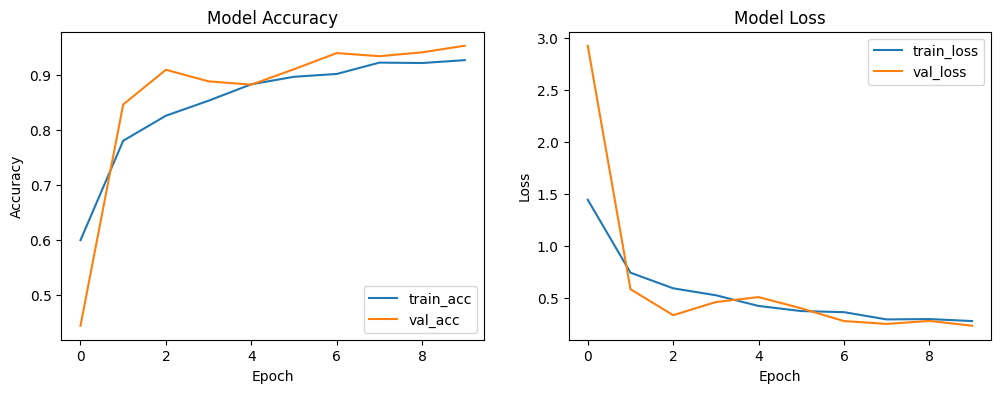

In [11]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


Plotting the model train and validation inorder to know if there is an overfitting

In [12]:
cnn_model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.9530 - loss: 0.2180


[0.24862602353096008, 0.9426666498184204]

Testing the model

In [13]:
loss, acc = cnn_model.evaluate(test_ds, verbose=0)
params = cnn_model.count_params()
size_mb = params * 4 / (1024**2)

print(f"Test Accuracy: {acc:.4f}")
print(f"Number of Parameters: {params/1e6:.2f}M")
print(f"Approx. Model Size: {size_mb:.2f} MB")

Test Accuracy: 0.9427
Number of Parameters: 22.25M
Approx. Model Size: 84.87 MB


Evaluating the model interms of number of parameters and model size

In [14]:
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)
cnn_model.save("cnn_model.h5", save_format="h5")

TensorFlow version: 2.18.0
Keras version: 3.8.0


In [15]:
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess
        
# ResNet50
resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
resnet_base.trainable = False

# EfficientNetB0
effnet_base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,))
effnet_base.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Pretrained models inisialization**

We have assined to them weights trained on imagenet and removed the top layer for dataset adaptation and made input resizing

In [16]:
def build_transfer_model(base_model, preprocess_layer, num_classes):
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation(inputs)
    x = preprocess_layer(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

**Transfer Lerning Model Preparation**

Resizing, data augmentation, preprocessing, freezing the model from training and Global average pooling and finally the activation function softmax and adam for lerning rate adaptation

In [17]:
from tensorflow.keras import layers, Model

models = {
    "ResNet50": build_transfer_model(resnet_base, resnet_preprocess, NUM_CLASSES),
    "EfficientNetB0": build_transfer_model(effnet_base, efficient_preprocess, NUM_CLASSES)
}

Making the preprocessing and putting the number of the dataset classes on each pretrained model

In [18]:
import time

histories = {}
training_times = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    start = time.time()
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1  # bzhr 2lprogress bta3 kol epoch
    )
    
    end = time.time()
    
    histories[name] = history
    training_times[name] = (end - start) / 60  # b7awl l minutes

    print(f"{name} training time: {training_times[name]:.2f} minutes\n")


Training ResNet50...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 167ms/step - accuracy: 0.8820 - loss: 0.4868 - val_accuracy: 0.9983 - val_loss: 0.0158
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9986 - loss: 0.0165 - val_accuracy: 0.9990 - val_loss: 0.0090
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 159ms/step - accuracy: 0.9988 - loss: 0.0080 - val_accuracy: 0.9990 - val_loss: 0.0053
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9998 - loss: 0.0041 - val_accuracy: 0.9990 - val_loss: 0.0037
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9999 - loss: 0.0024 - val_accuracy: 0.9990 - val_loss: 0.0040
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accuracy: 0.9997 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0025
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 159ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9990 - val_loss: 0.0023
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 159ms/step - accur

E0000 00:00:1766315971.766521      47 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 94ms/step - accuracy: 0.8708 - loss: 0.6628 - val_accuracy: 0.9967 - val_loss: 0.0378
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9962 - loss: 0.0411 - val_accuracy: 0.9973 - val_loss: 0.0200
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9973 - loss: 0.0211 - val_accuracy: 0.9987 - val_loss: 0.0113
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9978 - loss: 0.0149 - val_accuracy: 0.9983 - val_loss: 0.0082
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9987 - loss: 0.0104 - val_accuracy: 0.9990 - val_loss: 0.0059
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9995 - loss: 0.0067 - val_accuracy: 0.9990 - val_loss: 0.0049
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9992 - loss: 0.0057 - val_accuracy: 0.9990 - val_loss: 0.0049
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.9998 - loss: 0.0040 - val_accurac

Training the two models on our dataset

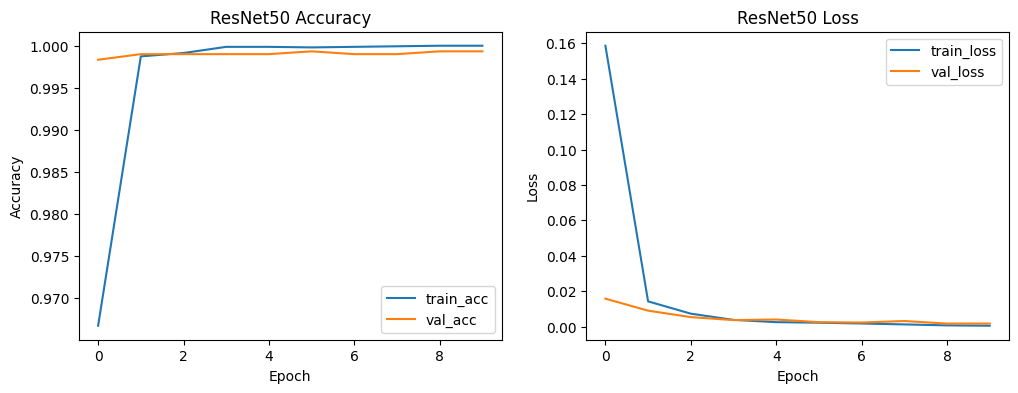

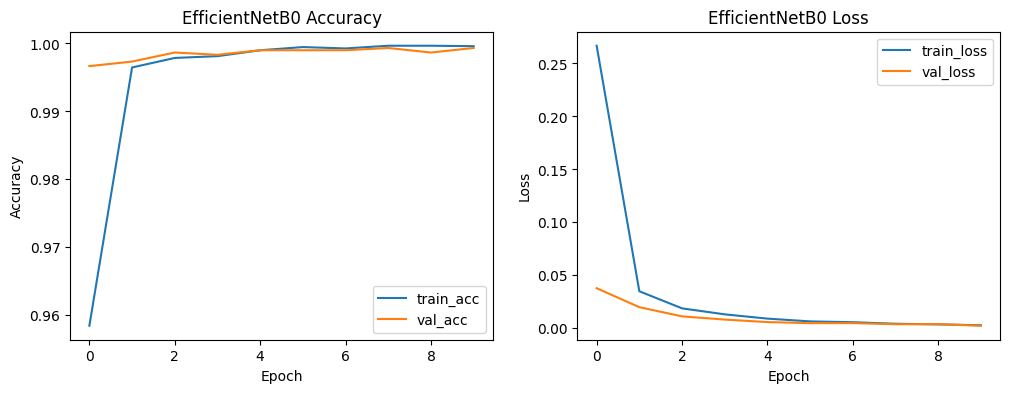

In [19]:
for name, history in histories.items():
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(f'{name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

In [20]:
# bnUnfreeze 2lbase model
resnet_base.trainable = True

# bnFreeze 2lbottom layers
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

# bnUnfreeze 2lbase model
effnet_base.trainable = True

# bnFreeze 2lbottom layers
for layer in effnet_base.layers[:-20]:
    layer.trainable = False

**Finetuning of Pretrained Models**

We have chosen to unfreeze the top layers of the two models to improve performance

In [21]:
models["ResNet50"].compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

models["EfficientNetB0"].compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**Finetuning of Pretrained Models**

We have chosen to unfreeze the top layers of the two models to improve performance

In [22]:
history_resnet_ft = models["ResNet50"].fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

history_effnet_ft = models["EfficientNetB0"].fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 113s 214ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.8907 - val_loss: 1.3316
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 208ms/step - accuracy: 0.9983 - loss: 0.0076 - val_accuracy: 0.9967 - val_loss: 0.0135
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9993 - val_loss: 0.0018
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 208ms/step - accuracy: 1.0000 - loss: 1.9450e-04 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 207ms/step - accuracy: 1.0000 - loss: 1.8352e-04 - val_accuracy: 0.9997 - val_loss: 0.0012
Epoch 1/5


E0000 00:00:1766316893.136562      47 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 101ms/step - accuracy: 0.9751 - loss: 0.1045 - val_accuracy: 0.9970 - val_loss: 0.0119
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9959 - loss: 0.0296 - val_accuracy: 0.9990 - val_loss: 0.0068
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - accuracy: 0.9976 - loss: 0.0175 - val_accuracy: 0.9993 - val_loss: 0.0047
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - accuracy: 0.9987 - loss: 0.0126 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - accuracy: 0.9992 - loss: 0.0089 - val_accuracy: 0.9993 - val_loss: 0.0028


Training the models after finetuning

In [23]:
models["EfficientNetB0"].save("efficientnetb0_finetuned.keras")

Saving the two models

In [24]:
cnn_params = cnn_model.count_params()
cnn_size = cnn_params * 4 / (1024 ** 2)  # 4 bytes per float32

resnet_params = models["ResNet50"].count_params()
resnet_size = resnet_params * 4 / (1024 ** 2)

effnet_params = models["EfficientNetB0"].count_params()
effnet_size = effnet_params * 4 / (1024 ** 2)


Saving the number of parameters in variables for comparison

In [25]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds)

resnet_loss, resnet_acc = models["ResNet50"].evaluate(test_ds)

effnet_loss, effnet_acc = models["EfficientNetB0"].evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9530 - loss: 0.2180
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.9990 - loss: 0.0021
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9985 - loss: 0.0032


Saving the evaluation of each model in variables for comparison

In [26]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "ResNet50 (Fine-tuned)", "EfficientNetB0 (Fine-tuned)"],
    "Test Accuracy": [cnn_acc, resnet_acc, effnet_acc],
    "Test Loss": [cnn_loss, resnet_loss, effnet_loss],
    "Params (Millions)": [cnn_params/1e6, resnet_params/1e6, effnet_params/1e6],
    "Model Size (MB)": [cnn_size, resnet_size, effnet_size]
})

comparison_df

,Model,Test Accuracy,Test Loss,Params (Millions),Model Size (MB)
0,Custom CNN,0.942667,0.248626,22.249423,84.874813
1,ResNet50 (Fine-tuned),0.999333,0.001374,23.618447,90.097225
2,EfficientNetB0 (Fine-tuned),0.999000,0.002793,4.068786,15.521187


Comparing the three models